https://velog.io/@be2be2/140725-01

# 6장. 로지스틱 회귀 모델: 참 거짓 판단하기

[<img src="https://raw.githubusercontent.com/taehojo/taehojo.github.io/master/assets/images/linktocolab.png" align="left"/> ](https://colab.research.google.com/github/taehojo/deeplearning/blob/master/colab/ch06-colab.ipynb)

## 5. 텐서플로에서 실행하는 로지스틱 회귀 모델

### 1.환경 준비

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. 데이터 준비

In [2]:
x = np.array([2, 4, 6, 8, 10, 12, 14])
y = np.array([0, 0, 0, 1, 1, 1, 1]) 

### 3. 모델 실행

In [ ]:
model = Sequential()


model.add(Dense(1, input_dim=1, activation='sigmoid'))

# 교차 엔트로피 오차 함수를 이용하기 위하여 'binary_crossentropy'로 설정합니다. 
model.compile(optimizer='sgd' ,loss='binary_crossentropy')

# 모델 설명
model.summary()

# 2. Output Shape: (None, 1) 의미
# (None, 1)

# ✔ None
# 배치 크기 (몇 개씩 넣을지)
# 실행 시점에 결정됨

# 예: 32개씩 넣으면 (32, 1)
# ✔ 1
# 뉴런이 1개라서 출력도 1개

# 👉 즉:

# “샘플 여러 개 들어오면 각각 1개 값 출력”

# 3. Param # = 2 이유 (핵심)

# 여기가 진짜 중요함.

# Dense(1), input_dim=1 이니까:

# ✔ 가중치 (weight)
# 입력 1개 × 출력 1개 = 1개

# ✔ bias (편향)
# 뉴런 1개니까 bias 1개
# 👉 총 파라미터 계산

# Param=(input×output)+bias
# =(1×1)+1=2

# 4. 내부 계산 구조

# 이 모델은 실제로 이렇게 계산함:

# z=wx+b

# 그 다음:

# y=sigmoid(z)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x, y, epochs=5000)

### 4. 모델 테스트

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


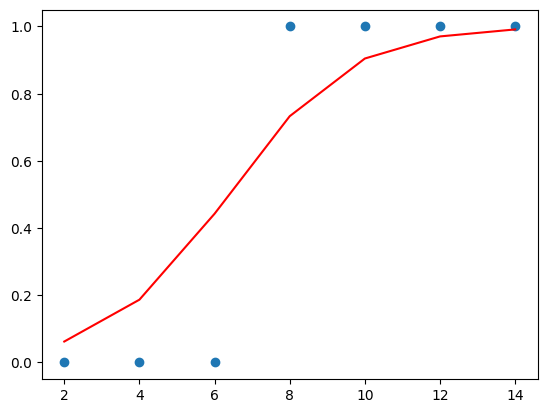

In [4]:
#그래프로 확인해 봅니다.

plt.scatter(x, y)
plt.plot(x, model.predict(x),'r')
plt.show()

In [12]:
#임의의 학습시간을 집어넣어 합격 예상 확률을 예측해 보겠습니다.

hour = 7
prediction = model.predict(np.array([hour]))
print(prediction)
print("%.f시간을 공부할 경우, 합격 예상 확률은 %.01f%%입니다" % (hour, prediction[0][0] * 100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.5962392]]
7시간을 공부할 경우, 합격 예상 확률은 59.6%입니다


## 로지스틱 회귀에서 “활성화 함수”는 선형 결과를 확률로 바꿔주는 핵심 장치임.
## 함수가 바로 시그모이드 함수

![alt text](image-9.png)

![alt text](image-10.png)

## 기울기 소실 문제(Vanishing Gradient)

![alt text](image-11.png)

![alt text](image-12.png)

시그모이드를 미분한 값의 최대치는 0.25 → 오차가 커도 수정이 1/4만 적용됨

![alt text](image-13.png)

#### 100점을 맞아야 하는데 0점이 나옴 → 수정을 100만큼 진행해야 해서 역전파 진행 → 시그모이드 미분으로 인해 1/4만 적용 → 최대 수정해도 25만큼만 수정됨

# 그래서 활성화 함수 종류가 몇가지 있음

![alt text](image-15.png)


## 최적화는 함수(Optimizer)

👉 1) 손실 함수 (Loss Function)
👉 2) 최적화 알고리즘 (Optimizer)


### 손실함수를 최소화하는 방법들

![alt text](image-14.png)


### 유형별 loss, activation
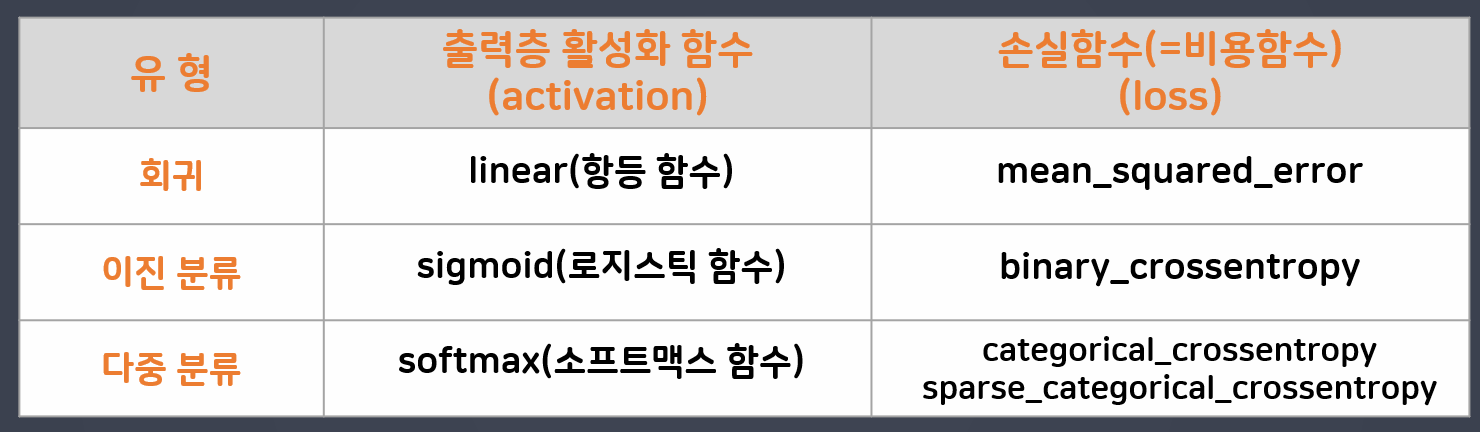